In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
#check if the values in the dataset are zero in some columns
df.isna().sum()

,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,5
Age,0
Distance,0
rad,0
tax,0


In [4]:
#if yes fill them with the mean value of the column
for column in df.columns:
  mean_value = df[column].mean()
  df[column].fillna(mean_value, inplace = True)

df.isna().sum()

/tmp/ipykernel_10643/77610746.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mean_value, inplace = True)


,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,0
Age,0
Distance,0
rad,0
tax,0


In [8]:
#select the input and output variable
x = df.drop('medv', axis=1)

y = df['medv']

In [9]:
#divide it into training, testing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
#create the ann
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Dense(128, input_shape=(13,), activation='relu', name='dense_layer_1'))
model.add(Dense(64, activation='relu', name='dense_layer_2'))
model.add(Dense(1, activation='linear', name='output_layer'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_layer_1 (Dense)           │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#train the ann on training data
history = model.fit(
    x_train,
    y_train,
    epochs = 100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 597.0550 - mae: 22.5021 - val_loss: 501.0745 - val_mae: 20.7456
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 530.6650 - mae: 20.9872 - val_loss: 433.6450 - val_mae: 19.1068
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 452.9310 - mae: 19.0753 - val_loss: 349.5731 - val_mae: 16.8880
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 352.5008 - mae: 16.4618 - val_loss: 248.8112 - val_mae: 13.8213
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 235.4270 - mae: 12.9644 - val_loss: 150.3059 - val_mae: 9.8679
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 132.4876 - mae: 9.1751 - val_loss: 83.4168 - val_mae: 6.6737
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 71.8463 - mae: 6.5766 - val_loss: 61.5248 - val_mae: 5.0650
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 48.8933 - mae: 5.3725 - val_loss: 55.6745 - val_mae: 4.8609
Epoch 9/100
11/11 ━━

In [14]:
#testing the model on test data
mse_nn, mae_nn = model.evaluate(x_test, y_test)

print("MSE on test data is: ", mse_nn)
print("MAE on test data is: ", mae_nn)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.0798 - mae: 2.1752
MSE on test data is:  11.079784393310547
MAE on test data is:  2.1751651763916016


In [15]:
#finding out the actual predicted values
y_pred = model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [16]:
#this line converts y_test into a numpy array and reshapes it into a column vector
y_test = np.array(y_test).reshape(-1, 1)

#np.array(y_test) ->
#before -> y_test = [24,18,10]
#after -> array([24.18,10])

#reshape(-1, 1) ->
#decide the number of rows automatically and 1 column
#before -> shape = (3,)
#after -> array([
#            [24],
#            [18],
#            [10]
#             ])  shape = (3,1)

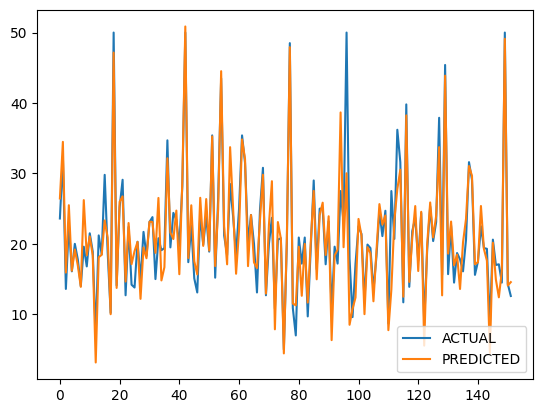

In [17]:
#Plot the actual vs predicted graph
plt.plot(y_test, label='ACTUAL')
plt.plot(y_pred, label='PREDICTED')
plt.legend()